In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, norm

20 lotes independentes com 50 estudantes cada (1000)

### Geração Aleatória

In [ ]:
NUM_BATCHES = 20
BATCH_SIZE = 50

media = 0
desvio_padrao = 1
limite_inferior = -3
limite_superior = 3

#np.random.seed(57) #gerei nessa pra testar, mas cada vez que rodar vai tá aleatório

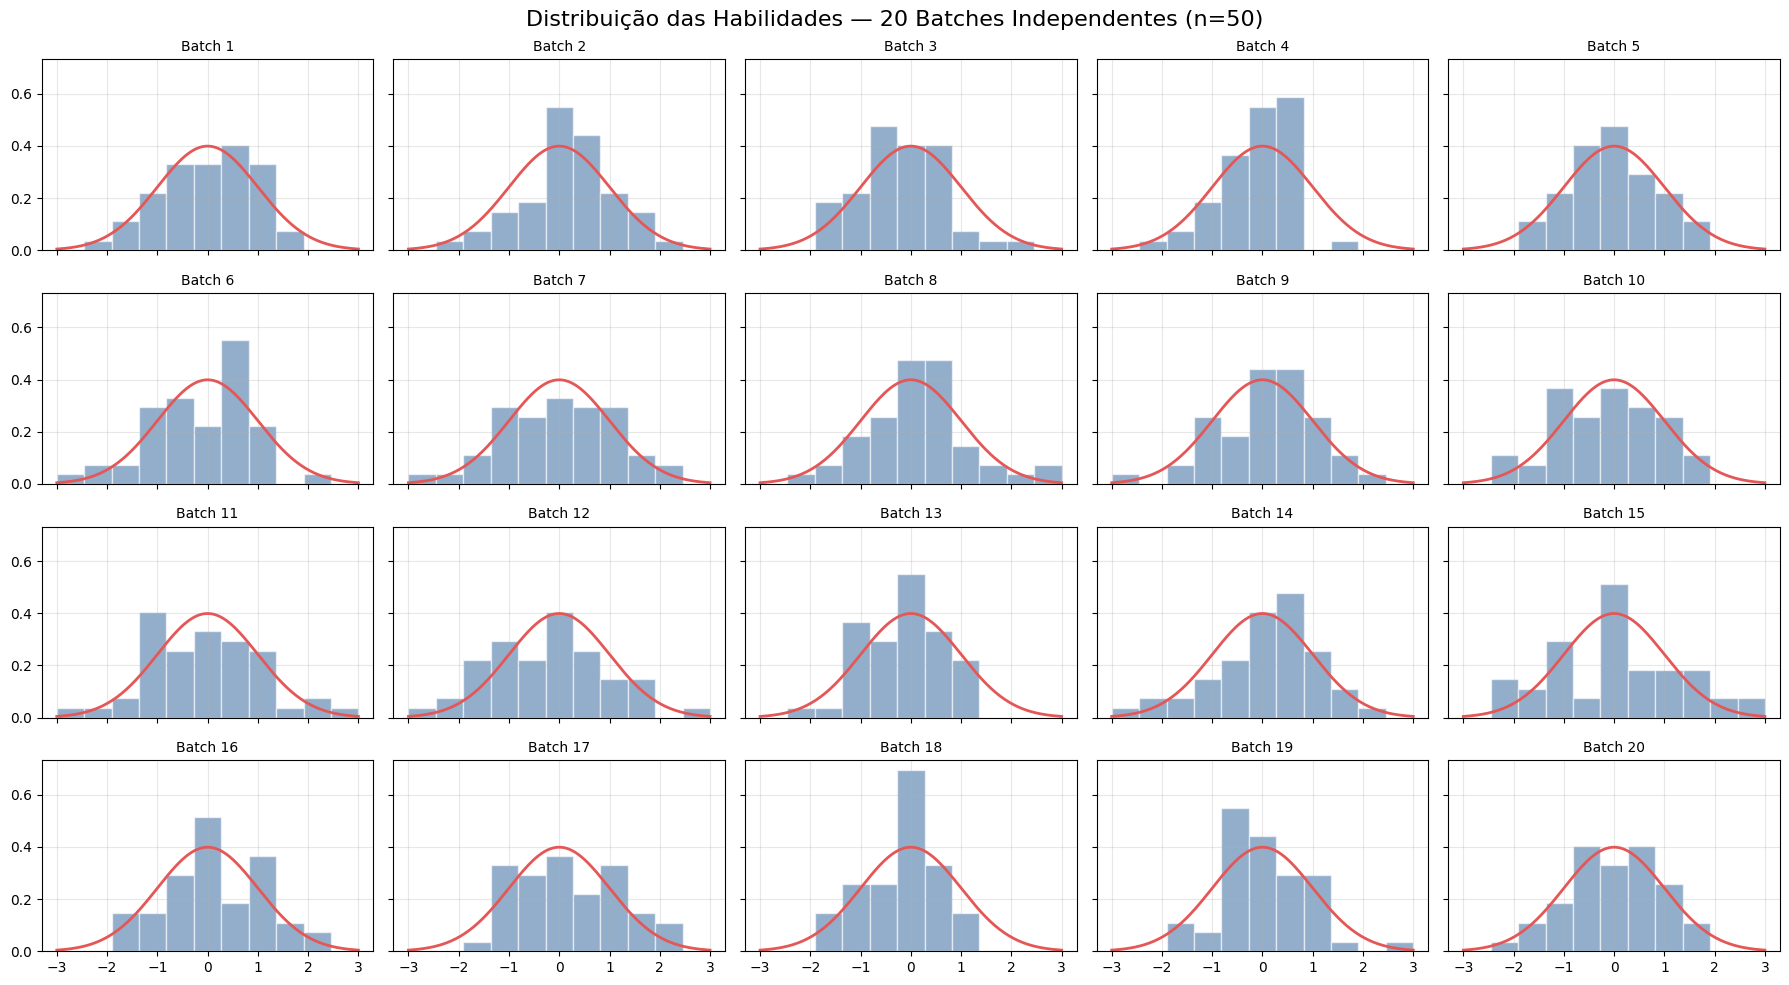

{
  "batches": [
    {
      "batch_id": 1,
      "estudantes": [
        {
          "id_estudante": "1",
          "habilidade": 1.0236
        },
        {
          "id_estudante": "2",
          "habilidade": 1.5824
        },
        {
          "id_estudante": "3",
          "habilidade": 1.13
        },
        {
          "id_estudante": "4",
          "habilidade": -1.6523
        },
        {
          "id_estudante": "5",
          "habilidade": -0.8765
        },
        {
          "id_estudante": "6",
          "habilidade": -0.4032
        },
        {
          "id_estudante": "7",
          "habilidade": -0.4674
        },
        {
          "id_estudante": "8",
          "habilidade": -0.8593
        },
        {
          "id_estudante": "9",
          "habilidade": 0.4565
        },
        {
          "id_estudante": "10",
          "habilidade": 0.6298
        },
        {
          "id_estudante": "11",
          "habilidade": 1.8188
        },
        {
      

In [ ]:
a = (limite_inferior - media) / desvio_padrao
b = (limite_superior - media) / desvio_padrao

batches = []

fig, axes = plt.subplots(4, 5, figsize=(18,10), sharex=True, sharey=True)
axes = axes.flatten()

x = np.linspace(-3,3,200)

student_id = 1

for i in range(NUM_BATCHES):

    dados = truncnorm.rvs(a, b, loc=media, scale=desvio_padrao, size=BATCH_SIZE)

    # salvar estudantes do batch
    students = [
        {
            "id_estudante": str(student_id + j),
            "habilidade": round(float(theta), 4)
        }
        for j, theta in enumerate(dados)
    ]

    batches.append({
        "batch_id": i + 1,
        "estudantes": students
    })

    student_id += BATCH_SIZE

    # plot
    ax = axes[i]

    ax.hist(
        dados,
        bins=np.linspace(-3,3,12),
        density=True,
        color="#4C78A8",
        alpha=0.6,
        edgecolor="white"
    )

    ax.plot(
        x,
        norm.pdf(x,0,1),
        color="#E45756",
        linewidth=2
    )

    ax.set_title(f"Batch {i+1}", fontsize=10)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Distribuição das Habilidades — 20 Batches Independentes (n=50)",
    fontsize=16
)

plt.tight_layout()
plt.show()

# exportar JSON
students_json = {"batches": batches}

print(json.dumps(students_json, indent=2))

In [23]:
with open("batches_estudantes.json", "w", encoding="utf-8") as f:
    json.dump(students_json, f, indent=2, ensure_ascii=False)

print("JSON salvo como batches_estudantes.json")

JSON salvo como batches_estudantes.json


### Transformar JSON em uma lista simples

Etapa necessária pois o n8n tem dificuldade pra ler objetos JSON no prompt, e estava sendo necessário usar o stringfy. Com isso, talvez fique mais simples e menos custoso.

In [24]:
with open("batches_estudantes.json", "r", encoding="utf-8") as f:
    data = json.load(f)

batches = data["batches"]

saida = []

for batch in batches:

    habilidades = "\n".join(
        str(s["habilidade"])
        for s in batch["estudantes"]
    )

    saida.append({
        "batch_id": batch["batch_id"],
        "habilidades": habilidades
    })

In [25]:
print(json.dumps(saida, indent=2, ensure_ascii=False))

[
  {
    "batch_id": 1,
    "habilidades": "1.0236\n1.5824\n1.13\n-1.6523\n-0.8765\n-0.4032\n-0.4674\n-0.8593\n0.4565\n0.6298\n1.8188\n0.6261\n0.7966\n-1.4851\n-0.3677\n-0.0498\n0.146\n1.355\n-0.4479\n0.0334\n0.8699\n-0.2347\n-1.6976\n0.0502\n0.9417\n0.3944\n-0.3715\n0.4918\n0.8032\n-0.134\n-0.0432\n-1.1266\n-1.0745\n-0.8315\n-0.7481\n-0.7433\n0.3664\n0.6077\n0.9262\n0.8696\n0.1377\n0.7835\n-0.3133\n-0.6122\n1.064\n1.0127\n-2.0315\n0.0425\n-1.0632\n0.6257"
  },
  {
    "batch_id": 2,
    "habilidades": "0.7678\n0.5648\n0.998\n0.1844\n0.5545\n0.2515\n1.0398\n-1.4315\n0.2601\n1.3427\n-0.6121\n-0.0027\n0.1677\n-0.1722\n0.5761\n0.1541\n0.3736\n-1.2651\n-0.3149\n-0.1587\n0.2459\n0.9136\n1.5799\n0.1367\n0.705\n-0.075\n0.4281\n0.0029\n1.4818\n-0.7145\n-0.6149\n2.0028\n0.3146\n-0.0562\n-1.0489\n0.7784\n-1.3637\n0.9086\n-2.1958\n1.3029\n0.2925\n1.8923\n0.1685\n-0.6666\n0.2859\n-1.1751\n0.5186\n-1.0155\n0.1709\n1.776"
  },
  {
    "batch_id": 3,
    "habilidades": "1.2135\n-1.6949\n-0.4032\n-0.

In [26]:
with open("batches_n8n.json", "w", encoding="utf-8") as f:
    json.dump(saida, f, indent=2)

print("Arquivo batches_n8n.json criado")

Arquivo batches_n8n.json criado
